In [1]:
# import library
import pandas as pd 
import numpy as np 

# visualization
import seaborn as sns
import matplotlib.pyplot as plt

# import date library
from datetime import datetime
from operator import attrgetter

import warnings
warnings.filterwarnings('ignore')

In [2]:
dekoruma_products = pd.read_csv('dekoruma_products_clean.csv')
dekoruma_products

,sku_id,product_name,category,is_assembly_required
0,SKU-FURN-00001,Furnitur Kayu Olahan 407,Office Chair,True
1,SKU-FURN-00002,Furnitur Kayu Olahan 536,Wardrobe,True
2,SKU-FURN-00003,Sofa Japandi Minimalis 867,Sofa,True
3,SKU-FURN-00004,Furnitur Kayu Olahan 727,Office Chair,True
4,SKU-FURN-00005,Furnitur Kayu Olahan 363,Wardrobe,True
...,...,...,...,...
1495,SKU-FURN-01496,Sofa Japandi Minimalis 932,Sofa,False
1496,SKU-FURN-01497,Furnitur Kayu Olahan 956,Wardrobe,True
1497,SKU-FURN-01498,Furnitur Kayu Olahan 774,Wardrobe,True
1498,SKU-FURN-01499,Furnitur Kayu Olahan 642,Dining Table,True


In [3]:
dekoruma_stores = pd.read_csv('dekoruma_stores_clean.csv')
dekoruma_stores

,store_id,store_name,channel_type
0,DKR-001,DEC Alam Sutera 1,Physical Store
1,DKR-002,DEC Bintaro 2,Physical Store
2,DKR-003,DEC Kemang 3,Physical Store
3,DKR-004,DEC Kelapa Gading 4,Physical Store
4,DKR-005,DEC Medan 5,Physical Store
5,DKR-006,DEC Kemang 6,Physical Store
6,DKR-007,DEC Surabaya 7,Physical Store
7,DKR-008,DEC Bandung 8,Physical Store
8,DKR-009,DEC Kelapa Gading 9,Physical Store
9,DKR-010,DEC Kemang 10,Physical Store


In [4]:
dekoruma_orders = pd.read_csv('dekoruma_orders_clean.csv')
dekoruma_orders

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
0,ORD-DKR00000001,DKR-029,SKU-FURN-00208,2023-08-10 17:00:00,2023-08-14 17:00:00,TUKANG-0882,2023-08-18 17:00:00,Success,120000
1,ORD-DKR00000002,DKR-012,SKU-FURN-01157,2023-01-30 10:00:00,2023-02-02 10:00:00,TUKANG-0560,2023-02-02 10:00:00,Success,110000
2,ORD-DKR00000003,DKR-032,SKU-FURN-00904,2023-07-13 20:00:00,2023-07-19 20:00:00,TUKANG-0631,2023-07-24 20:00:00,Success,230000
3,ORD-DKR00000004,DKR-005,SKU-FURN-00341,2023-09-27 19:00:00,2023-10-02 19:00:00,TUKANG-0484,2023-10-04 19:00:00,Success,100000
4,ORD-DKR00000005,DKR-019,SKU-FURN-01500,2023-12-15 12:00:00,2023-12-22 12:00:00,Not Applicable,NaN,No Assembly Service,0
...,...,...,...,...,...,...,...,...,...
295425,ORD-DKR00299996,DKR-019,SKU-FURN-01096,2023-01-26 10:00:00,2023-01-28 10:00:00,TUKANG-0585,2023-01-30 10:00:00,Success,90000
295426,ORD-DKR00299997,DKR-012,SKU-FURN-00579,2023-11-28 12:00:00,2023-12-04 12:00:00,Not Applicable,NaN,No Assembly Required,0
295427,ORD-DKR00299998,DKR-029,SKU-FURN-00252,2023-07-23 13:00:00,2023-07-29 13:00:00,TUKANG-0796,2023-08-01 13:00:00,Success,160000
295428,ORD-DKR00299999,DKR-031,SKU-FURN-01007,2023-09-06 11:00:00,2023-09-11 11:00:00,Not Applicable,NaN,No Assembly Required,0


In [5]:
dekoruma_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 295430 entries, 0 to 295429
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   order_id             295430 non-null  str  
 1   store_id             295430 non-null  str  
 2   sku_id               295430 non-null  str  
 3   order_date           295430 non-null  str  
 4   delivery_date        295430 non-null  str  
 5   installer_id         295430 non-null  str  
 6   installation_date    185705 non-null  str  
 7   installation_status  295430 non-null  str  
 8   assembly_fee         295430 non-null  int64
dtypes: int64(1), str(8)
memory usage: 51.8 MB


In [6]:
dekoruma_orders['order_date'] = pd.to_datetime(dekoruma_orders['order_date'])
dekoruma_orders['delivery_date'] = pd.to_datetime(dekoruma_orders['delivery_date'])
dekoruma_orders['installation_date'] = pd.to_datetime(dekoruma_orders['installation_date'])

In [7]:
dekoruma_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 295430 entries, 0 to 295429
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             295430 non-null  str           
 1   store_id             295430 non-null  str           
 2   sku_id               295430 non-null  str           
 3   order_date           295430 non-null  datetime64[us]
 4   delivery_date        295430 non-null  datetime64[us]
 5   installer_id         295430 non-null  str           
 6   installation_date    185705 non-null  datetime64[us]
 7   installation_status  295430 non-null  str           
 8   assembly_fee         295430 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(5)
memory usage: 37.7 MB


# Rata-rata waktu yang dibutuhkan (dalam hari) untuk proses Instalasi setelah barang diterima pelanggan.

**LATAR BELAKANG MASALAH :**  
**Pengiriman barang berukuran besar (Bulky Goods) seperti lemari pakaian 3 pintu atau kitchen set memicu masalah operasional yang sangat kompleks. Berbeda dengan mengirim paket skincare, mengirim furnitur membutuhkan armada truk khusus dan yang paling krusial: Jasa Perakitan (*Installation Service*). Keluhan pelanggan mulai membanjiri media sosial karena jadwal pengiriman dan perakitan yang sering tidak sinkron. Contohnya ada banyak kasus di mana kasur dan kerangka ranjang diantar pada hari Senin, tetapi tim tukang rakit (Installer) baru datang pada hari Kamis, membuat rumah pelanggan berantakan dipenuhi kardus flat-pack.**


**ANALISIS :**  
**Pada segmen analisis ini kita akan mencoba melihat selisih waktu antara barang diterima dan kedatangan tukang rakit (*Installer/Assembler*), sekaligus melihat bagaimana pencatatan dan ketersediaan data yang ada.**

- Pertama kita eksplor dulu data nya untuk melihat apa saja yang bisa kita pakai dalam proses analisis ini.

In [8]:
dekoruma_orders.shape
dekoruma_orders['installation_status'].value_counts()

installation_status
Success                   147787
No Assembly Required       76030
No Assembly Service        33695
Failed - Missing Parts     22639
Failed - Damaged Panel     15279
Name: count, dtype: int64

Dari data di atas, bisa dilihat bahwa kita punya 3 jenis data *installation status*, yaitu:  
1. Berhasil dirakit (*Success*)
2. Tidak ada Perakitan, baik karena memang barang tidak butuh perakitan, ataupun pelanggan yang memilih untuk merakit sendiri (*No Assembly Required* dan *No Assembly Service*)
3. Perakitan gagal, baik karena kekurangan komponen (*Failed - Missing Parts*) ataupun kerusakan komponen (*Failed - Damaged Panel*)

Yang akan kita gunakan adalah yang berstatus *Success* dan *Failed*, karena *Failed* status bukan berarti tukang rakit tidak datang atau tidak butuh rakit, melainkan rakitnya gagal. Terlihat di bawah bahwa ada interval antara installation date dan delivery date, membuktikan tukang rakit tetap datang.

In [9]:
dekoruma_orders.loc[dekoruma_orders['installation_status'] == 'Failed - Damaged Panel', ['delivery_date', 'installation_date', 'installation_status']]

,delivery_date,installation_date,installation_status
28,2023-02-02 17:00:00,2023-02-03 17:00:00,Failed - Damaged Panel
39,2023-12-29 12:00:00,2024-01-02 12:00:00,Failed - Damaged Panel
40,2023-03-28 20:00:00,2023-04-01 20:00:00,Failed - Damaged Panel
77,2023-06-24 19:00:00,2023-06-25 19:00:00,Failed - Damaged Panel
103,2023-05-29 11:00:00,2023-06-02 11:00:00,Failed - Damaged Panel
...,...,...,...
295371,2023-01-24 16:00:00,2023-01-26 16:00:00,Failed - Damaged Panel
295389,2023-02-03 10:00:00,2023-02-06 10:00:00,Failed - Damaged Panel
295404,2023-08-02 11:00:00,2023-08-07 11:00:00,Failed - Damaged Panel
295415,2023-02-06 20:00:00,2023-02-09 20:00:00,Failed - Damaged Panel


- Pertama kita mem-filter transaksi yang memang tidak ada proses perakitan

In [10]:
# mem-filter installation status yang tidak ada proses perakitan

no_assembly = ['No Assembly Required', 'No Assembly Service']
assembled = dekoruma_orders[~dekoruma_orders['installation_status'].isin(no_assembly)].copy()

print(assembled['installation_status'].value_counts())
print(f"\nOrders with assembler visit: {len(assembled):,}")

installation_status
Success                   147787
Failed - Missing Parts     22639
Failed - Damaged Panel     15279
Name: count, dtype: int64

Orders with assembler visit: 185,705


Proses di atas menunjukkan terdapat 185,705 pesanan yang terjadi perakitan, terlepas dari berhasil atau tidak nya. Data ini yang akan kita pakai untuk melihat rentang waktu kedatangan tukang rakit, dengan proses di bawah ini:

In [11]:
assembled['days_to_install'] = (
    assembled['installation_date'] - assembled['delivery_date']
).dt.days

# Descriptive statistics
assembled['days_to_install'].describe().round(2)

count    185705.00
mean          2.51
std           1.71
min           0.00
25%           1.00
50%           3.00
75%           4.00
max           5.00
Name: days_to_install, dtype: float64

**Terdapat 185,705 transaksi yang masuk akal (Perakitan terjadi setelah barang tiba/dikirim). Rata-rata (*mean*) waktu yang dibutuhkan (dalam hari) antara barang diterima dan proses perakitan adalah 2,51 hari.**

Di bawah ini adalah bar chart yang menunjukkan transaksi keseluruhan dan waktu yang dibutuhkan (dalam hari) untuk proses instalasi.

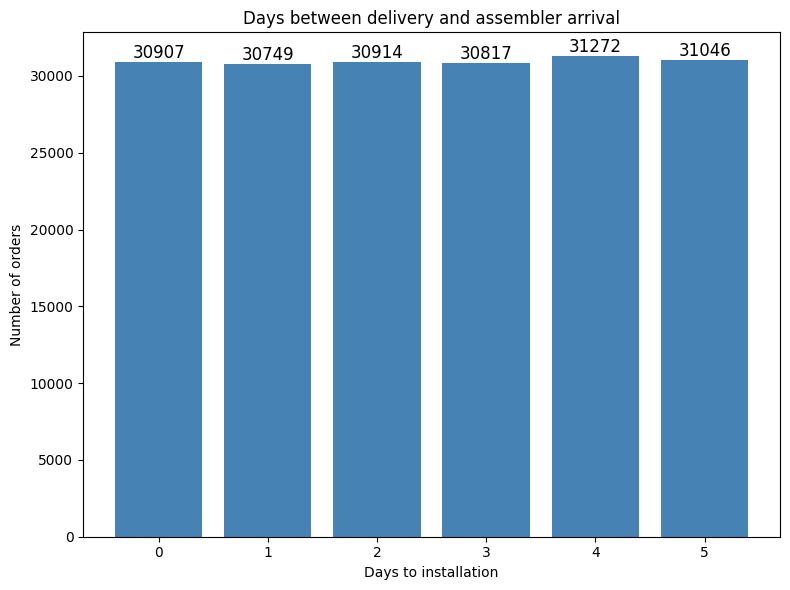

In [12]:
import matplotlib.pyplot as plt

counts = assembled['days_to_install'].value_counts().sort_index()

plt.figure(figsize=(8, 6))

bars = plt.bar(counts.index, counts.values, color='steelblue')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=12)

plt.xlabel('Days to installation')
plt.ylabel('Number of orders')
plt.title('Days between delivery and assembler arrival')
plt.tight_layout()
plt.show()

Maka kita dapat rata-rata rentang waktu kehadiran tukang rakit dari barang diterima adalah 2,51 hari.

**KESIMPULAN :**
- **Rata-rata rentang waktu kehadiran tukang rakit dari barang diterima adalah 2,51 hari.**

**INSIGHT/TEMUAN :**
- **Rentang waktu yang cukup lama dari barang diterima pelanggan sampai proses perakitan menyebabkan barang yang tiba "nganggur" selama beberapa hari sebelum dapat digunakan oleh pelanggan. Hal ini beresiko tinggi nya tingkat ketidak-puasan pelanggan pasca pembelian (*post-purchase experience*).**
- **Berpacu pada proses pembersihan data (*Data Cleansing*) Terdapat banyak kesalahan data logistik baik karena salah input maupun salah pencatatan yang dapat menyebabkan tim *Business Intelligence* kewalahan dalam mengelola dan menganalisa produk akibat pesanan yang kotor.**

**SARAN :**
- **Membangun sistem atau peraturan yang mewajibkan jadwal kedatangan barang (Truk) dan tukang rakit terjadi di hari yang sama (Maksimal selisih 24 jam). Semakin cepat barang yang tiba dapat digunakan pelanggan diharapkan semakin tinggi tingkat kepuasan nya.**
- **Menutup bug sistem agar tanggal perakitan tidak bisa di-input mendahului tanggal resi pengiriman berstatus *Delivered* (*Anti-Logical Error*).**

# Kategori furnitur yang paling sering mengalami kegagalan perakitan

**LATAR BELAKANG MASALAH :**  
**Seperti yang sudah kita temukan di segmen analisis sebelumnya, ternyata sering kali ditemukan bahwa komponen furnitur tersebut kurang (misal: baut hilang, engsel kurang) atau panel kayunya retak saat transit (Damaged/Missing Parts). Akibatnya, perakitan dibatalkan (Failed Installation), pelanggan marah besar, dan tim logistik harus melakukan retur barang. Biaya logistik untuk me-retur barang bulky ini luar biasa mahal dan langsung menggerogoti margin keuntungan (Net Profit) dari produk tersebut.**

**ANALISIS :**  
**Pada segmen ini, kita ingin melihat furnitur apa saja yang paling sering mengalami kegagalan rakit, ada berapa kasus untuk masing-masing kategori furnitur, bagaimana rasio kegagalan nya, serta menganalisa apa keterkaitan nya antara tingkat/rasio gagal rakit dengan jenis/kategori furnitur.**

- Identifikasi ada berapa pesanan yang mengalami kegagalan perakitan, sekaligus mem-filter pesanan gagal rakit.

In [13]:
failed_statuses = ['Failed - Missing Parts', 'Failed - Damaged Panel']
failed = dekoruma_orders[dekoruma_orders['installation_status'].isin(failed_statuses)]

print(failed['installation_status'].value_counts())
print(f"\nTotal failed orders: {len(failed):,}")

installation_status
Failed - Missing Parts    22639
Failed - Damaged Panel    15279
Name: count, dtype: int64

Total failed orders: 37,918


- Left join antara data failed orders(left) dengan table dekoruma_products untuk mendapatkan kolom 'category', dengan key sku_id.

In [14]:
merged = failed.merge(
    dekoruma_products[['sku_id', 'category']],
    on='sku_id',
    how='left'
)
print(merged.shape)

(37918, 10)


- Melihat kategori furnitur yang paling banyak mengalami kegagalan perakitan, sekaligus melihat rasio kegagalan nya.

In [15]:
total = dekoruma_orders.merge(dekoruma_products[['sku_id', 'category']], on='sku_id', how='left')
total_by_cat  = total.groupby('category').size().rename('total_orders')
failed_by_cat = merged.groupby('category').size().rename('failed_orders')

result = pd.concat([total_by_cat, failed_by_cat], axis=1).dropna()
result['failure_rate_%'] = (
    result['failed_orders'] / result['total_orders'] * 100
).round(2)

# result.sort_values('failed_orders', ascending=False)
result_sorted = result.sort_values('failed_orders', ascending=False)
result_sorted

,total_orders,failed_orders,failure_rate_%
category,,,
Wardrobe,68377,11737.0,17.17
Office Chair,64607,11082.0,17.15
Dining Table,45502,7930.0,17.43
Sofa,42611,3121.0,7.32
Bed,15354,2682.0,17.47
Sofabed,16003,1366.0,8.54


In [16]:
result.sort_values('failure_rate_%', ascending=False)

,total_orders,failed_orders,failure_rate_%
category,,,
Bed,15354,2682.0,17.47
Dining Table,45502,7930.0,17.43
Wardrobe,68377,11737.0,17.17
Office Chair,64607,11082.0,17.15
Sofabed,16003,1366.0,8.54
Sofa,42611,3121.0,7.32


- **Terlihat dari tabel di atas kasus kegagalan rakit tertinggi adalah kategori Wardrobe dan Office Chair, masing-masing mencapai lebih dari 11.000 pesanan.**  
- **Sementara rasio kegagalan rakit tertinggi mencapai lebih dari 17%.**  
- **Bed dan Dining Table memiliki rasio kegagalan tertinggi padahal jumlah pesanan lebih sedikit dibandingkan Wardrobe dan Office Chair.**

Untuk melihat lebih jelas informasi tentang kasus kegagalan rakit kita gunakan Pareto chart.

- Pertama, Pareto chart dengan melihat total kasus kegagalan rakit (*failed orders*) dengan rasio kegagalan dalam % (*failure rate*).

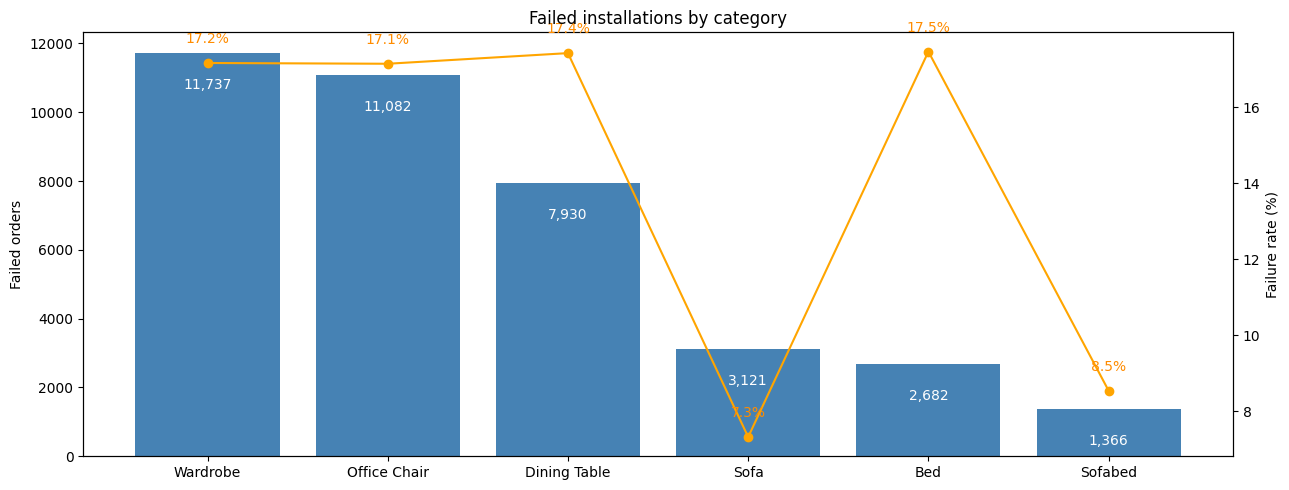

In [17]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

bars = ax1.bar(result_sorted.index, result_sorted['failed_orders'], color='steelblue', label='Failed count')
line = ax2.plot(result_sorted.index, result_sorted['failure_rate_%'], color='orange', marker='o', label='Failure rate %')

for bar in bars:
    ax1.annotate(
        f"{int(bar.get_height()):,}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, -18),
        textcoords='offset points',
        ha='center', va='top',
        fontsize=10, color='white'
    )

for x, y in zip(result_sorted.index, result_sorted['failure_rate_%']):
    ax2.annotate(
        f"{y:.1f}%",
        xy=(x, y),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=10, color='darkorange'
    )

ax1.set_ylabel('Failed orders')
ax2.set_ylabel('Failure rate (%)')
plt.title('Failed installations by category')
plt.tight_layout()
plt.show()

- Kemudian kita lihat total pesanan secara kesuluruhan tiap kategori (*total orders*) dan rasio kegagalan (*failure rate*).

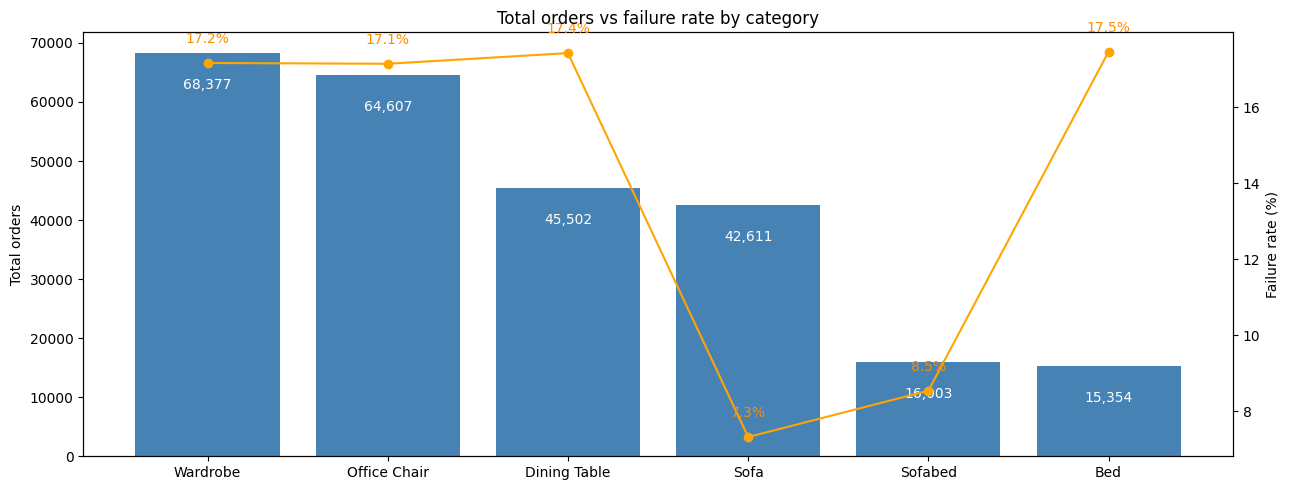

In [18]:
result_sorted = result.sort_values('total_orders', ascending=False)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

bars = ax1.bar(result_sorted.index, result_sorted['total_orders'], color='steelblue', label='Total orders')
line = ax2.plot(result_sorted.index, result_sorted['failure_rate_%'], color='orange', marker='o', label='Failure rate %')

for bar in bars:
    ax1.annotate(
        f"{int(bar.get_height()):,}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, -18),
        textcoords='offset points',
        ha='center', va='top',
        fontsize=10, color='white'
    )

for x, y in zip(result_sorted.index, result_sorted['failure_rate_%']):
    ax2.annotate(
        f"{y:.1f}%",
        xy=(x, y),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=10, color='darkorange'
    )

ax1.set_ylabel('Total orders')
ax2.set_ylabel('Failure rate (%)')
plt.title('Total orders vs failure rate by category')
plt.tight_layout()
plt.show()

Dari 2 visualisasi di atas kita dapat melihat bahwa:
1. Rasio kegagalan mayoritas bernilai 17%, tetapi ada kategori seperti Sofa dan Sofabed yang rasio kegagalan nya hanya sekitar 7-8,5%.
2. Ada dua kategori yaitu Dining Table dan Bed yang memiliki rasio kegagalan hampir sama tetapi total pesanan nya jauh lebih sedikit.

**Oleh karena itu, perlu kita uji secara statistik, apakah kategori furnitur berkaitan dengan rasio kegagalan rakit?**

Uji statistik yang kita gunakan di sini adalah **Uji Independensi Chi-squared** (*Chi-square test of independence*). Alasan nya karena kita akan menggunakan 2 variabel yaitu:
1. *count* dari kasus gagal (*failed*) tiap kategori, vs
2. *count* dari kasus berhasil (*NOT failed*) tiap kategori.

Yang dimana keduanya merupakan data *categorical*

Kita tidak menggunakan rasio kegagalan nya itu sendiri (*failure rate (%)*), karena tingkat kegagalan per kategori hanya memberikan 6 angka — satu angka per kategori.  
Kita tidak dapat menarik kesimpulan yang bermakna hanya dari 6 pengamatan.

Jika p < 0,05 → tolak H₀ → tingkat kegagalan secara signifikan terkait dengan kategori  
Jika p >= 0,05 → gagal menolak H₀ → tidak ada perbedaan signifikan antar kategori

- Di bawah ini adalah tabel (dataframe) yang akan kita gunakan:

In [19]:
contingency = pd.DataFrame({
    'failed': failed_by_cat,
    'not_failed': total_by_cat - failed_by_cat
}).dropna()

contingency

,failed,not_failed
category,,
Bed,2682.0,12672.0
Dining Table,7930.0,37572.0
Office Chair,11082.0,53525.0
Sofa,3121.0,39490.0
Sofabed,1366.0,14637.0
Wardrobe,11737.0,56640.0


Dari tabel diatas kita bisa mendapatkan *Degrees of Freedom (DoF)* menggunakan formula:  
(number of rows − 1) × (number of columns − 1).  

yang dimana, Rows = 6 (one per category: Wardrobe, Office Chair, Dining Table, Sofa, Bed, Sofabed).  
Columns = 2 (Failed, Not Failed).

Maka:
DoF yang kita gunakan = (6 − 1) × (2 − 1) = 5 × 1 = 5

- Di bawah ini adalah kode untuk uji statistik *Chi-square test of independence* :

In [20]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic : {chi2:.2f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p:.6f}")

Chi-square statistic : 3259.76
Degrees of freedom   : 5
P-value              : 0.000000


P-value < 0,05 → tolak H₀.  
Artinya tingkat kegagalan rakit secara signifikan terkait dengan kategori furnitur. Kategori seperti Bed (17,47%) dan Dining Table (17,43%) menunjukkan tingkat kegagalan yang jauh lebih tinggi dibandingkan dengan Sofa (7,32%) dan Sofabed (8,54%).

**KESIMPULAN :**
- **Kasus kegagalan perakitan terbanyak terjadi pada kategori Wardrobe dan Office Chair, yang masing-masing mencapai 11 ribu pesanan.**
- **Akan tetapi, kategori furnitur yang paling sering mengalami kegagalan perakitan adalah Bed dan Dining Table yang masing-masing mencapai lebih dari 17% rasio kegagalan.**

**INSIGHT/TEMUAN :**
- **Melihat tinggi nya jumlah pesanan untuk kategori Wardrobe dan Office Chair, masih masuk akal jika kasus kegagalan nya juga tinggi. Tetapi jika melihat rasio kegagalan nya, kategori Bed dan Dining Table rasio kegagalan nya cukup tinggi jika dibandingkan dengan total jumlah pesanan.**
- **Berdasarkan uji Chi-squared, menunjukkan bahwa tingkat kegagalan rakit dipengaruhi oleh jenis/kategori furnitur.** 

**SARAN :**
- **Kategori furnitur Bed dan Dining Table perlu diberikan perhatian khusus karena tinggi nya rasio kegagalan rakit, bahkan dengan jumlah order yang cenderung jauh lebih sedikit dari kateori lain seperti Wardrobe dan Office Chair.** 
- **Tukang rakit perlu diberikan *warning* dan/atau pelatihan ulang untuk proses perakitan jenis-jenis furnitur tertentu, karena tingkat kegagalan rakit sangat bergantung/dipengaruhi oleh jenis/kategori furnitur nya.**

# Toko dengan kasus kegagalan rakit akibat komponen kurang (*Missing Parts*)

**LATAR BELAKANG MASALAH :**  
**Dari segmen analisis sebelumnya, jelas terlihat banyaknya Kasus kegagalan rakit akibat kekurangan komponen (*Missing Parts*). Kasus ini adalah tanggung jawab toko sebagai penyedia barang. Hal ini perlu diatasi karena selain menyebabkan kerugian perusahaan secara logistik, juga dapat menyebabkan tingginya tingkat ke-tidakpuasan pelanggan.**

**ANALISIS :**  
**Pada segmen ini, kita akan mencoba mengatasi masalah tersebut dengan mengidentifikasi toko-toko mana saja yang terjadi kegagalan rakit akibat kekurangan komponen, dan melihat persebaran nya, apakah ada toko-toko tertentu dengan performa jelek, ataukah masalah ini lebih sistemik di semua toko.**

- Pertama kita lihat daftar toko yang terjadi kasus kegagalan rakit akibat kekurangan komponen atau *Missing parts*

In [21]:
missing = dekoruma_orders[dekoruma_orders['installation_status'] == 'Failed - Missing Parts']

missing_by_store = (
    missing.groupby('store_id')
    .size()
    .reset_index(name='total_missing_parts')
)

result = missing_by_store.merge(
    dekoruma_stores[['store_id', 'store_name']],
    on='store_id',
    how='left'
)

stores_missing_parts = result[['store_id', 'store_name', 'total_missing_parts']]

stores_missing_parts = stores_missing_parts.sort_values('total_missing_parts', ascending=False).reset_index(drop=True)

stores_missing_parts

,store_id,store_name,total_missing_parts
0,DKR-034,DEC Bintaro 34,606
1,DKR-029,DEC Kelapa Gading 29,603
2,DKR-010,DEC Kemang 10,594
3,DKR-037,DEC Kelapa Gading 37,593
4,DKR-035,DEC Surabaya 35,592
5,DKR-018,DEC Alam Sutera 18,591
6,DKR-008,DEC Bandung 8,586
7,DKR-032,DEC Medan 32,585
8,DKR-022,DEC Alam Sutera 22,584
9,DKR-003,DEC Kemang 3,581


- Akan lebih jelas terlihat persebaran nya menggunakan Bar chart, berikut di bawah ini adalah Top 10 Toko yang paling banyak kegagalan rakit nya diakibatkan oleh kekurangan komponen:

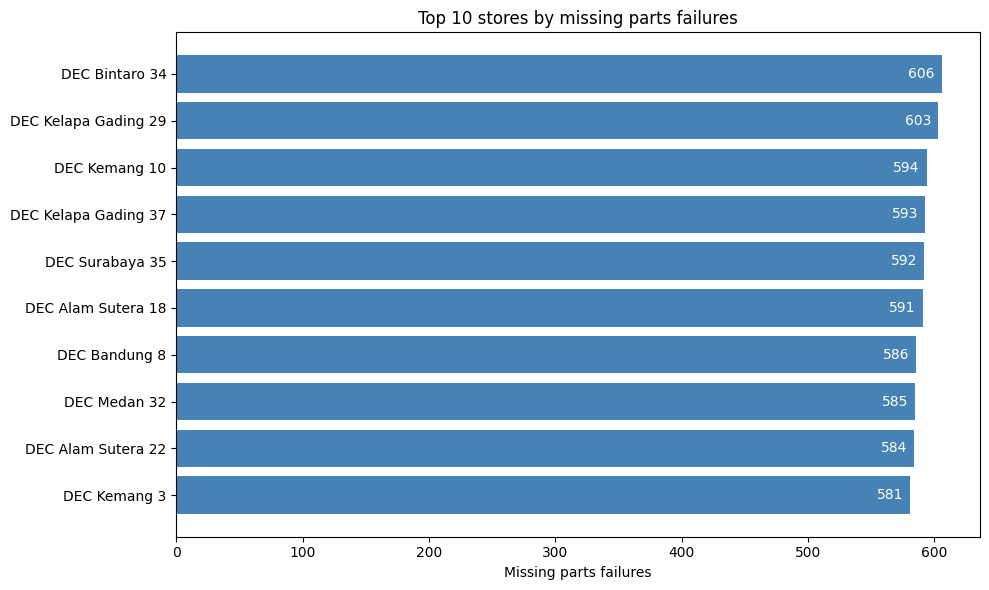

In [22]:
top10 = stores_missing_parts.head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(top10['store_name'], top10['total_missing_parts'], color='steelblue')
plt.xlabel('Missing parts failures')
plt.title('Top 10 stores by missing parts failures')
plt.gca().invert_yaxis()

for bar in bars:
    plt.annotate(
        f"{int(bar.get_width()):,}",
        xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
        xytext=(-5, 0),
        textcoords='offset points',
        ha='right', va='center',
        fontsize=10, color='white'
    )

plt.tight_layout()
plt.show()

**Berdasarkan tabel dan bar chart di atas terlihat kegagalan rakit akibat kekurangan komponen terjadi di semua toko, dengan persebaran/distribusi jumlah kasus nya hampir merata.**  
**Sekarang kita buktikan distribusi nya dengan menggunakan 2 cara:**  
1. **Melihat nilai minimal dan maximal, kemudian hitung range nya**
2. **Menggunakan Uji Kecocokan Chi-squared (*Chi-square goodness of fit test*)**

- Melihat statistika deskriptif untuk menunjukkan nilai minimal, maksimal, dan range.

In [23]:
stores_missing_parts['total_missing_parts'].describe()

count     40.000000
mean     565.975000
std       22.350916
min      504.000000
25%      551.500000
50%      571.000000
75%      579.500000
max      606.000000
Name: total_missing_parts, dtype: float64

In [24]:
print(f"Range: {stores_missing_parts['total_missing_parts'].max() - stores_missing_parts['total_missing_parts'].min()}")

Range: 102


Dari data di atas, terlihat:  
Nilai minimal : 504  
Nilai maksimal : 606  
Range : 102

Berdasarkan ketiga nilai tersebut, kita sudah bisa melihat distribusi kegagalan rakit akibat kekurangan komponen yang merata di semua toko.

- Untuk lebih pasti, mari kita buktikan lebih jauh dengan menggunakan Chi-squared.

H₀: Kegagalan akibat kekurangan komponen terdistribusi secara merata  
H₁: Kegagalan akibat kekurangan komponen TIDAK terdistribusi  merata (ada toko yang memiliki tingkat kegagalan yang signifikan dibanding yang lain)

In [25]:
from scipy.stats import chisquare

observed = stores_missing_parts['total_missing_parts']

expected_value = observed.sum() / len(observed)

chi2, p = chisquare(f_obs=observed, f_exp=[expected_value] * len(observed))

print(f"Chi-square statistic : {chi2:.4f}")
print(f"P-value              : {p:.6f}")
print(f"Expected per store   : {expected_value:.1f}")

Chi-square statistic : 34.4237
P-value              : 0.678533
Expected per store   : 566.0


P-value = 0.678, dimana dia >= 0,05. Terima H₀  
Maka terbukti bahwa kegagalan rakit akibat kekurangan komponen (*Missing parts*) terdistribusi secara merata.

**KESIMPULAN :**
- **Kasus kegagalan perakitan akibat kekurangan komponen (*Missing Parts*) terjadi di semua toko**
- **Jumlah Kasus kegagalan tersebut tersebar secara merata, hampir semua toko memiliki jumlah kasus yang hampir sama**

**INSIGHT/TEMUAN :**
- **Mengindikasikan masalah kegagalan rakit bersifat sistemik di semua toko, bukan masalah yang terbatas pada lokasi/toko tertentu.**

**SARAN :**
- **Perlu ditinjau kembali pada rantai pasokan (*supply chain*) dan pengendalian mutu (*quality control*), kemudian segera di-tindaklanjuti agar kasus kegagalan rakit akibat kurang nya komponen tidak terjadi lagi.** 

# Toko sebagai keperluan *showrooming* (Transaksi menggunakan app, tetapi pelanggan berdomisili di dekat toko fisik)

**LATAR BELAKANG MASALAH :**  
**Ada dugaan bahwa banyak pelanggan yang melihat barang di DEC fisik, lalu pulang dan membelinya via aplikasi. Hal ini dikhawatirkan membuat performa toko fisik terlihat buruk di sistem, padahal toko tersebut berfungsi krusial sebagai tempat display (Showrooming).**  

**ANALISIS :**  
**Maka pada segmen analisis ini kita akan mengidentifikasi apakah ada transaksi yang menggunakan app tetapi pelanggan berdomisili di dekat toko fisik.**

Untuk mengidentifikasi fenomena ini, kita lihat berdasarkan transaksi dengan kode toko DKR-039 (kode untuk app), dan delivery date nya trjadi di hari yang sama atau satu hari setelah order date.

Logika nya adalah jika barang dapat tiba di hari yang sama, atau +1 hari setelah order (untuk menimbang kemungkinan order terjadi setelah jam kerja sehingga barang diantar esok hari nya) maka pelanggan kemungkinan berdomisili di radius dekat salah satu toko fisik.

- Pertama kita filter order yang store_id nya DKR-039

In [26]:
app_orders = dekoruma_orders[dekoruma_orders['store_id'] == 'DKR-039'].copy()
print(f"Total order dari channel Application: {len(app_orders)}")

Total order dari channel Application: 7348


- Lalu kita filter transaksi yang delivery date nya terjadi di hari yang sama dengan order date dan satu hari setelahnya

In [27]:
app_orders['days_to_deliver'] = (app_orders['delivery_date'] - app_orders['order_date']).dt.days

near_radius = app_orders[app_orders['days_to_deliver'].isin([0, 1])]
print(f"Transaksi dekat toko: {len(near_radius)}")

Transaksi dekat toko: 0


In [28]:
print(f"Min days_to_deliver: {app_orders['days_to_deliver'].min()}")
print(f"Max days_to_deliver: {app_orders['days_to_deliver'].max()}")

Min days_to_deliver: 2
Max days_to_deliver: 7


**berdasarkan data yang kita punya, ternyata tidak ada transaksi di App yang berasal dari pelanggan berdomisili dekat toko fisik.  
Waktu yang dibutuhkan untuk pengantaran barang mulai dari 2 hari hingga 7 hari.**   

Dapat dilihat lebih jelas dengan chart di bawah ini:

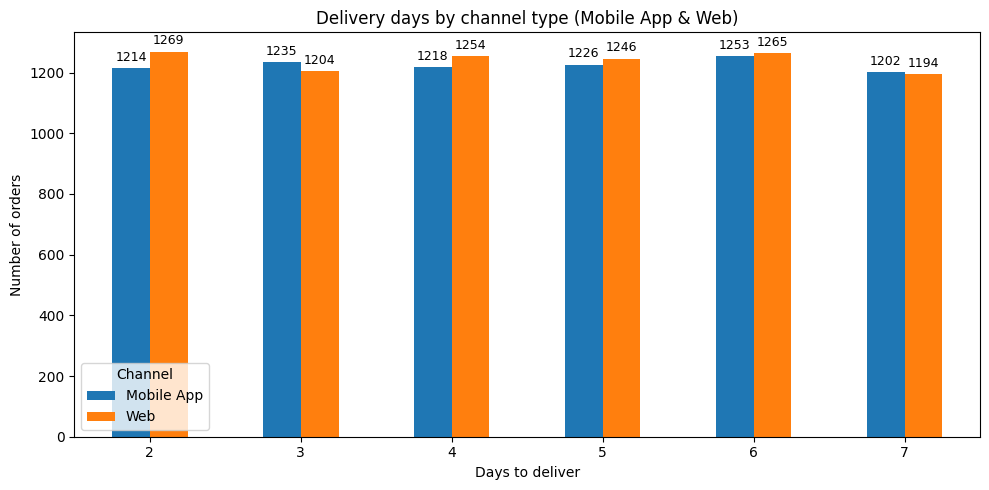

In [29]:
merged_all = dekoruma_orders.merge(
    dekoruma_stores[['store_id', 'channel_type']],
    on='store_id',
    how='left'
)

merged_all['order_date'] = pd.to_datetime(merged_all['order_date'])
merged_all['delivery_date'] = pd.to_datetime(merged_all['delivery_date'])
merged_all['days_to_deliver'] = (merged_all['delivery_date'] - merged_all['order_date']).dt.days

pivot = merged_all.groupby(['channel_type', 'days_to_deliver']).size().unstack()

pivot_digital = pivot.loc[['Mobile App', 'Web']]

fig, ax = plt.subplots(figsize=(10, 5))
pivot_digital.T.plot(kind='bar', ax=ax)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        label_type='edge',
        fontsize=9,
        color='black',
        rotation=0,
        padding=3
    )

ax.set_xlabel('Days to deliver')
ax.set_ylabel('Number of orders')
ax.set_title('Delivery days by channel type (Mobile App & Web)')
ax.legend(title='Channel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**KESIMPULAN :**  
- **Tidak ada transaksi yang di-attribusi ke app tetapi pelanggan berdomisili dekat toko fisik. Faktanya, minimal watu tiba untuk order menggunakan app adalah 2 hari, bahkan bisa sampai 7 hari.**

**INSIGHT :**
- **Toko-toko fisik yang ada cukup baik dalam melakukan promosi lokal, sehingga pelanggan mau datang.**
- **Pelanggan memilih untuk datang langsung ke toko untuk melakukan pesanan daripada menggunakan app jika memungkinkan.**
- **Akan tetapi, hasil dari analisis ini berdasarkan ketersediaan data yang kita miliki, yang dimana sebenarnya kurang lengkap jika kita ingin hasil yang lebih pasti.**

**SARAN :**
- **Jika ingin melihat dugaan adanya transaksi melalui app/web tetapi pelanggan berdomisili dekat salah satu toko fisik, maka butuh data yang lebih lengkap, bisa berupa alamat pelanggan dan alamat toko fisik yang lebih lengkap.**